# SHAP Beeswarm — 프로모션 / 비프로모션 Top 10

In [1]:
import sys
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from sklearn.base import clone

from cache import load_df, load_artifact
from config import RANDOM_STATE

# 한국어 폰트
for font in ["Malgun Gothic", "NanumGothic", "AppleGothic"]:
    try:
        fm.findfont(fm.FontProperties(family=font), fallback_to_default=False)
        plt.rcParams["font.family"] = font
        break
    except Exception:
        continue
plt.rcParams["axes.unicode_minus"] = False

KO = {
    "retention_w2_ratio":     "2주차 시청 유지율",
    "retention_w3_ratio":     "3주차 시청 유지율",
    "is_cold_start_3d":       "가입 후 3일 내 미시청",
    "drama_ratio":            "드라마 시청 비율",
    "romance_ratio":          "로맨스 시청 비율",
    "thriller_crime_ratio":   "스릴러/범죄 시청 비율",
    "family_animation_ratio": "가족/애니메이션 시청 비율",
    "watch_time(min)_w3":     "3주차 총 시청 시간",
    "action_adventure_ratio": "액션/어드벤처 시청 비율",
    "max_watch_time(min)":    "최대 1회 시청 시간",
    "diff_between_w3_w2":     "3→2주차 시청 변화량",
    "diff_between_w2_w1":     "2→1주차 시청 변화량",
    "diff_between_w3_w1":     "3→1주차 시청 변화량",
    "median_watch_time(min)": "중간 시청 시간",
    "genre_diversity_count":  "장르 다양성 수",
    "is_churn_prevented":     "이탈 방지 이력",
    "is_basic":               "베이직 요금제",
    "avg_watch_time(min)":    "평균 시청 시간",
    "horror_ratio":           "공포 시청 비율",
    "is_w1_over_50pct":       "1주차 시청 50% 이상",
    "is_only_w1":             "1주차에만 시청",
    "age_group":              "연령대",
    "max_day_share":          "특정 요일 집중도",
    "watch_time(min)_w1":     "1주차 총 시청 시간",
    "sf_fantasy_ratio":       "SF/판타지 시청 비율",
}

print("설정 완료")

설정 완료


In [2]:
import shap

def compute_shap(scope_key, n_sample=2000):
    exp_df = load_df("expanded_dataset")
    model  = load_artifact(f"tuned_model_{scope_key}")

    if scope_key == "promotion_only":
        df_scope = exp_df[exp_df["is_promotion"] == 1].copy()
        exclude  = {"USER_KEY", "is_repurchase", "is_promotion"}
    else:
        df_scope = exp_df[exp_df["is_promotion"] == 0].copy()
        exclude  = {"USER_KEY", "is_repurchase", "is_promotion"}

    features = [c for c in exp_df.columns if c not in exclude and c in df_scope.columns]

    X = df_scope[features].apply(pd.to_numeric, errors="coerce").fillna(0)
    y = (1 - df_scope["is_repurchase"].astype(int)).to_numpy()

    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(len(X), min(n_sample, len(X)), replace=False)
    X_sample = X.iloc[idx].reset_index(drop=True)

    fitted = clone(model)
    fitted.fit(X, y)

    explainer = shap.TreeExplainer(fitted)
    vals = explainer.shap_values(X_sample)
    if isinstance(vals, list):
        vals = vals[1] if len(vals) > 1 else vals[0]
    vals = np.asarray(vals)
    if vals.ndim == 3:
        vals = vals[:, :, 1] if vals.shape[2] > 1 else vals[:, :, 0]

    return vals, X_sample, features

print("함수 정의 완료")

함수 정의 완료


In [3]:
def plot_beeswarm(scope_key, title, out_name, top_n=10):
    shap_vals, X_sample, features = compute_shap(scope_key)

    # top_n 피처만 선택해서 넘기면 "Sum of other features" 행이 생기지 않음
    mean_abs = np.abs(shap_vals).mean(axis=0)
    top_idx  = np.argsort(mean_abs)[::-1][:top_n]

    top_shap     = shap_vals[:, top_idx]
    top_X        = X_sample.iloc[:, top_idx]
    top_features = [features[i] for i in top_idx]
    top_names_ko = [KO.get(f, f) for f in top_features]

    explanation = shap.Explanation(
        values=top_shap,
        data=top_X.values,
        feature_names=top_names_ko
    )

    shap.plots.beeswarm(explanation, max_display=top_n, show=False)

    plt.title(title, fontsize=14, fontweight="bold", pad=14)
    plt.xlabel("SHAP 값  (+ : 이탈 위험 증가 / − : 이탈 위험 감소)", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"cache/{out_name}", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"저장 완료: cache/{out_name}")

print("플롯 함수 정의 완료")

플롯 함수 정의 완료


C:\Users\USER\AppData\Local\Temp\ipykernel_26552\3589770312.py:23: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_26552\3589770312.py:24: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  plt.savefig(f"cache/{out_name}", dpi=150, bbox_inches="tight")
c:\Users\USER\anaconda4\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


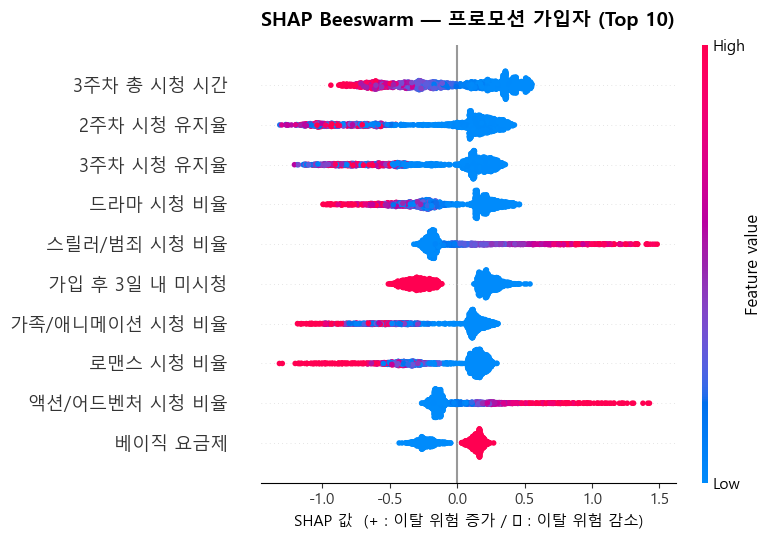

저장 완료: cache/shap_beeswarm_promotion.png


In [4]:
# 프로모션 가입자
plot_beeswarm(
    "promotion_only",
    "SHAP Beeswarm — 프로모션 가입자 (Top 10)",
    "shap_beeswarm_promotion.png",
)

C:\Users\USER\AppData\Local\Temp\ipykernel_26552\3589770312.py:23: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_26552\3589770312.py:24: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  plt.savefig(f"cache/{out_name}", dpi=150, bbox_inches="tight")
c:\Users\USER\anaconda4\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


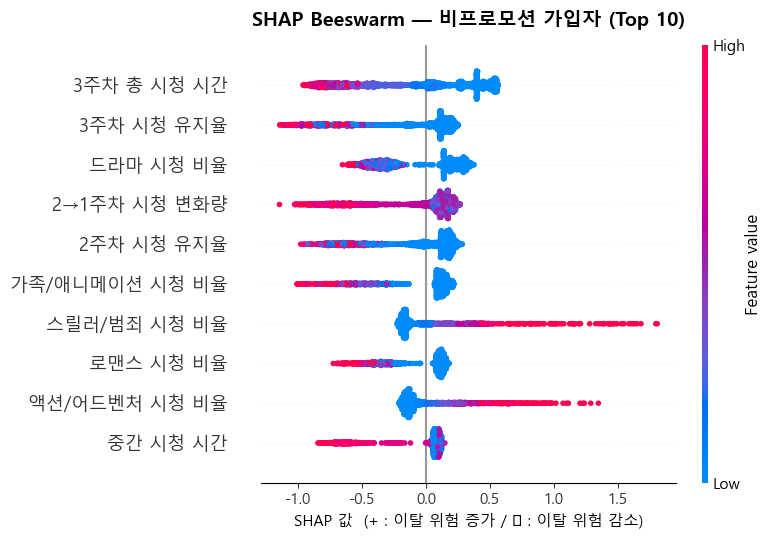

저장 완료: cache/shap_beeswarm_nonpromotion.png


In [5]:
# 비프로모션 가입자
plot_beeswarm(
    "nonpromotion_only",
    "SHAP Beeswarm — 비프로모션 가입자 (Top 10)",
    "shap_beeswarm_nonpromotion.png",
)